In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
daily_returns = pd.read_excel("daily_returns.xlsx")
daily_returns.head()


,Date,HDFCBANK,ICICIBANK,SBIN,TCS,INFY,HCLTECH,BAJAJ-AUTO,M&M,MARUTI,...,HINDALCO,LT,ULTRACEMCO,ADANIPORTS,BHARTIARTL,TATACOMM,INDUSTOWER,TITAN,DMART,TRENT
0,2023-02-02,-1.4869,1.1734,0.1422,1.5271,2.1049,1.5458,-0.5405,0.0259,1.1552,...,-0.5237,-0.0303,0.3676,-6.6041,1.1247,0.9439,-1.1777,-1.6113,-1.3643,-0.4441
1,2023-02-03,3.4584,0.6877,3.0487,0.6329,0.9882,-0.3001,1.6316,2.6324,0.8134,...,-1.2355,1.0094,0.3007,7.8711,1.9479,1.0463,0.7010,6.7155,-0.9292,2.0692
2,2023-02-06,-0.4250,-1.1692,0.2205,-0.6418,-1.8476,-0.0392,-0.0896,-0.8646,-0.3836,...,-2.6760,-0.4823,-0.8617,9.3415,-0.4603,2.5724,12.8089,-0.2071,-0.8313,-0.4492
3,2023-02-07,0.1483,-0.1113,0.3117,0.3642,-0.4746,-1.5231,0.7885,-0.6759,-1.6339,...,-3.9790,0.4267,-0.7780,1.4117,-0.4245,-1.9475,-1.0491,-0.4516,-0.0174,-1.3779
4,2023-02-08,-0.0121,0.7446,0.4844,1.3693,1.7985,1.4846,0.0219,0.4646,0.8246,...,1.6180,-1.5910,2.5248,8.3341,-1.3742,0.9039,0.4054,0.8112,0.5144,1.8876


In [6]:
stock_categories = pd.read_excel("stock_categories.xlsx")
stock_categories.head()

,Category,Symbol,Company Name
0,Banking & Finance,HDFCBANK,HDFC Bank
1,Banking & Finance,ICICIBANK,ICICI Bank
2,Banking & Finance,SBIN,State Bank of India
3,Information Tech,TCS,TCS
4,Information Tech,INFY,Infosys


In [7]:
daily_returns.columns

Index(['Date', 'HDFCBANK', 'ICICIBANK', 'SBIN', 'TCS', 'INFY', 'HCLTECH',
       'BAJAJ-AUTO', 'M&M', 'MARUTI', 'HINDUNILVR', 'ITC', 'NESTLEIND',
       'RELIANCE', 'NTPC', 'POWERGRID', 'SUNPHARMA', 'DRREDDY', 'CIPLA',
       'JSWSTEEL', 'TATASTEEL', 'HINDALCO', 'LT', 'ULTRACEMCO', 'ADANIPORTS',
       'BHARTIARTL', 'TATACOMM', 'INDUSTOWER', 'TITAN', 'DMART', 'TRENT'],
      dtype='object')

In [8]:
# Computing the correlation
returns = daily_returns.drop(columns=["Date"])

corr = returns.corr()

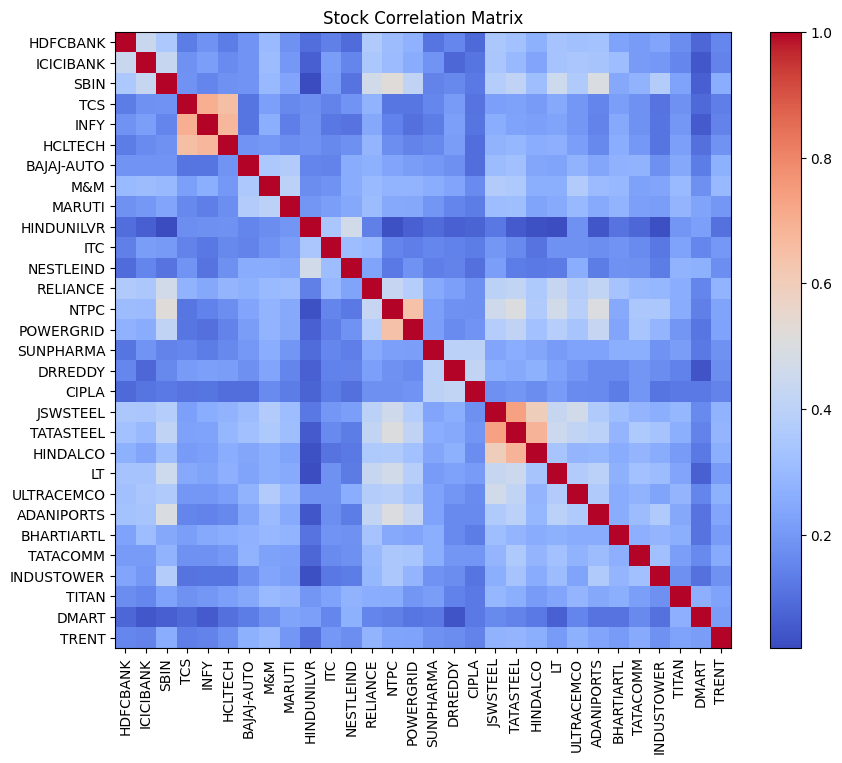

In [12]:
# Visualizing the correlation

plt.figure(figsize=(10, 8))
plt.imshow(corr, interpolation='nearest', cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Stock Correlation Matrix")
plt.show()

In [17]:
# Constructing 10 stocks based on correlation
returns.columns = returns.columns.str.strip().str.upper()
stock_categories["Symbol"] = stock_categories["Symbol"].str.strip().str.upper()

avg_corr = corr.mean()
selected_stocks = [avg_corr.idxmin()]

while len(selected_stocks) < 10:
    remaining = [s for s in corr.columns if s not in selected_stocks]

    avg_corr_with_selected = {
        stock: corr.loc[stock, selected_stocks].mean()
        for stock in remaining
    }

    next_stock = min(avg_corr_with_selected, key=avg_corr_with_selected.get)
    selected_stocks.append(next_stock)

selected_df = pd.DataFrame({"Symbol": selected_stocks})

final_selection = selected_df.merge(
    stock_categories[["Symbol", "Category"]],
    on="Symbol",
    how="left"
)

final_selection.columns = ["Stock", "Sector"]

print("\nFinal 10-Stock Portfolio with Sectors:\n")
print(final_selection)



Final 10-Stock Portfolio with Sectors:

        Stock              Sector
0  HINDUNILVR      Consumer Goods
1        SBIN   Banking & Finance
2       CIPLA     Pharmaceuticals
3       DMART   Retail/E-commerce
4        INFY    Information Tech
5  BAJAJ-AUTO         Automobiles
6  INDUSTOWER  Telecommunications
7         ITC      Consumer Goods
8    HDFCBANK   Banking & Finance
9   SUNPHARMA     Pharmaceuticals


In [21]:
# Efficient frontier analysis

selected_returns = returns[final_selection['Stock']]

# Annualization factor (assuming daily returns)
TRADING_DAYS = 252

mu = selected_returns.mean().values * TRADING_DAYS
Sigma = selected_returns.cov().values * TRADING_DAYS

n = len(final_selection['Stock'])

rf = 0.065  # 6.5%

In [39]:
num_portfolios = 50000

results = np.zeros((num_portfolios, 3))  # return, risk, sharpe
weights_record = []

for i in range(num_portfolios):
    w = np.random.random(n)
    w = w / np.sum(w)  # enforce sum=1

    weights_record.append(w)

    port_return = np.dot(w, mu)
    port_var = np.dot(w.T, np.dot(Sigma, w))
    port_std = np.sqrt(port_var)

    sharpe = (port_return - rf) / port_std

    results[i] = [port_return, port_std, sharpe]

In [41]:
# Max Sharpe
max_sharpe_idx = np.argmax(results[:, 2])
w_max_sharpe = weights_record[max_sharpe_idx]

# Global Minimum Variance
min_var_idx = np.argmin(results[:, 1])
w_gmv = weights_record[min_var_idx]

print("Max Sharpe Weights:", w_max_sharpe)
print("GMV Weights:", w_gmv)

Max Sharpe Weights: [0.02415685 0.26567913 0.04361611 0.02167357 0.05515766 0.32694131
 0.15452382 0.01651219 0.00713423 0.08460513]
GMV Weights: [0.14425757 0.03765703 0.09654236 0.079655   0.07652556 0.08256251
 0.02082974 0.12338566 0.18676757 0.151817  ]


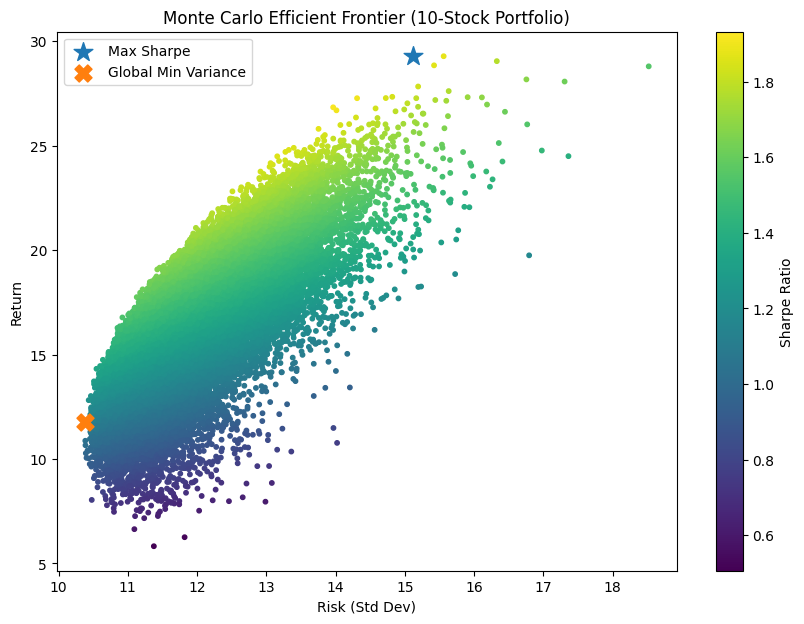

In [42]:
plt.figure(figsize=(10, 7))

# Scatter: portfolios
scatter = plt.scatter(
    results[:, 1],  # risk
    results[:, 0],  # return
    c=results[:, 2],  # sharpe
    cmap='viridis',
    s=10
)

plt.colorbar(scatter, label='Sharpe Ratio')

# Max Sharpe
plt.scatter(
    results[max_sharpe_idx, 1],
    results[max_sharpe_idx, 0],
    marker='*',
    s=200,
    label='Max Sharpe'
)

# GMV
plt.scatter(
    results[min_var_idx, 1],
    results[min_var_idx, 0],
    marker='X',
    s=150,
    label='Global Min Variance'
)


plt.xlabel("Risk (Std Dev)")
plt.ylabel("Return")
plt.title("Monte Carlo Efficient Frontier (10-Stock Portfolio)")
plt.legend()
plt.show()

In [43]:
portfolio_stocks = pd.DataFrame(
    {
        'Stock': final_selection['Stock'],
        'GMV_weights': w_gmv,
        'Max_Sharpe_weights': w_max_sharpe
    }
)

portfolio_stocks

,Stock,GMV_weights,Max_Sharpe_weights
0,HINDUNILVR,0.144258,0.024157
1,SBIN,0.037657,0.265679
2,CIPLA,0.096542,0.043616
3,DMART,0.079655,0.021674
4,INFY,0.076526,0.055158
5,BAJAJ-AUTO,0.082563,0.326941
6,INDUSTOWER,0.020830,0.154524
7,ITC,0.123386,0.016512
8,HDFCBANK,0.186768,0.007134
9,SUNPHARMA,0.151817,0.084605
